<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/*PS1-%20School%20Districts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [45]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [46]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [47]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School_Districts___Unified_7341673536716239500.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('School_Districts_Unified.shp') #labeled shapefile njSch

<Axes: >

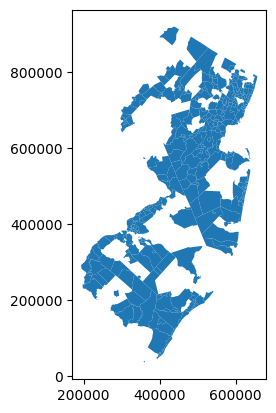

In [48]:
njSch.plot()

In [49]:
len(njSch)

339

In [50]:
njSch.dtypes #School District Headings

,0
NJDOE_ID_U,object
DIST_NAME,object
UNSDLEA,object
SD_TYPE,object
GEOID,object
geometry,geometry


In [56]:
njSch.rename(columns={'DIST_NAME' : 'NAME'}, inplace=True)
njSch['NAME'] = njSch['NAME'].str.upper()
njSch.rename(columns={'NJDOE_ID_U' : 'DistrictCode'}, inplace=True)
njSch['last_four_numbers_including_0_DistrictCode'] = njSch['DistrictCode'].str.split('-').str[1]
njSch['DistrictCode'] = njSch['DistrictCode'].astype(str).str.lstrip('0')
njSch['DistrictCode'].astype(np.int64)

NameError: name 'np' is not defined

In [ ]:
njSch

In [ ]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth%202024%20-%202025.xlsx', header = 3)

In [ ]:
DisXls.dtypes

In [ ]:
DisXls1=DisXls [['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']].copy()
DisXls1.rename(columns={'DistrictName' : 'NAME'}, inplace=True)
DisXls1['NAME'] = DisXls1['NAME'].str.upper()

DisXls1

In [ ]:
a1 = pd.merge(njSch, DisXls1, left_on='DistrictCode', right_on='DistrictCode', how='outer', indicator=True)
a1

In [57]:
a1._merge.value_counts()

NameError: name 'a1' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )